<a href="https://colab.research.google.com/github/ADHEERA12/Thiranx-DataScience-1/blob/main/FourthProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

/tmp/ipykernel_3491/1451454692.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_3491/1451454692.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

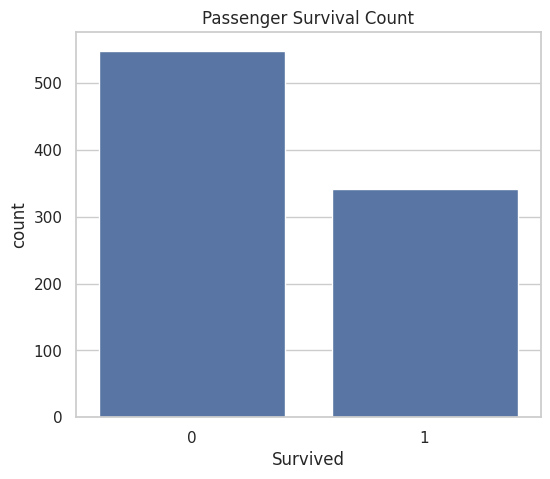

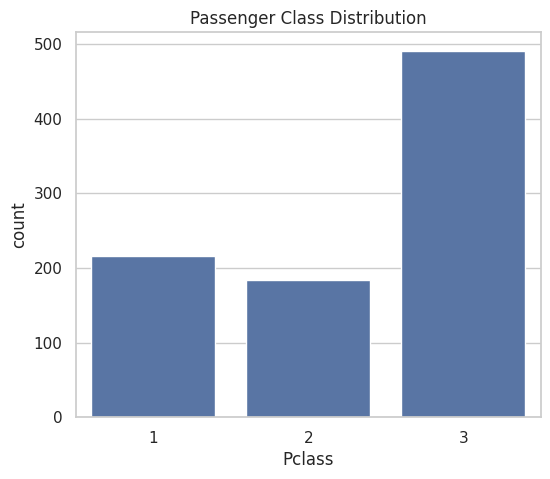

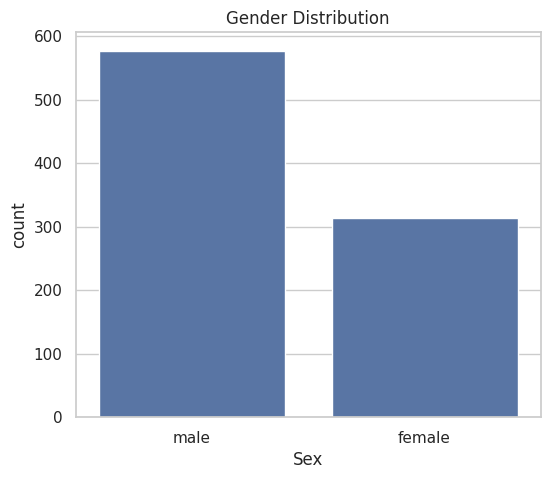

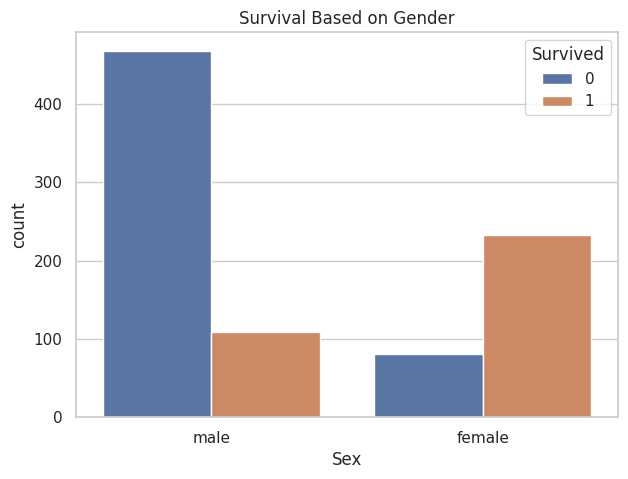

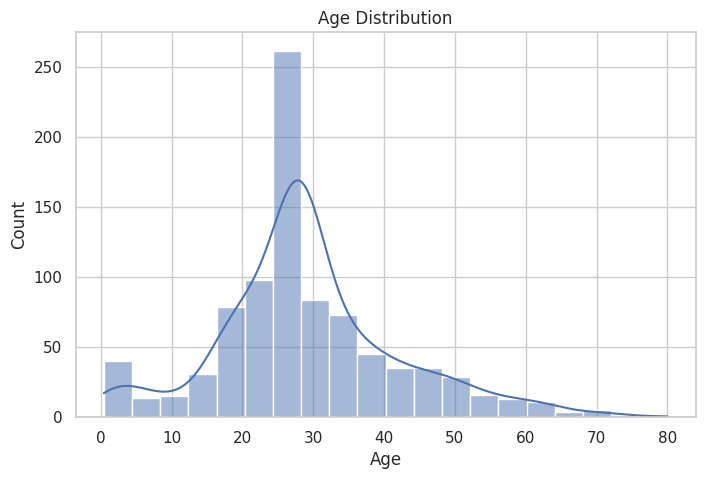

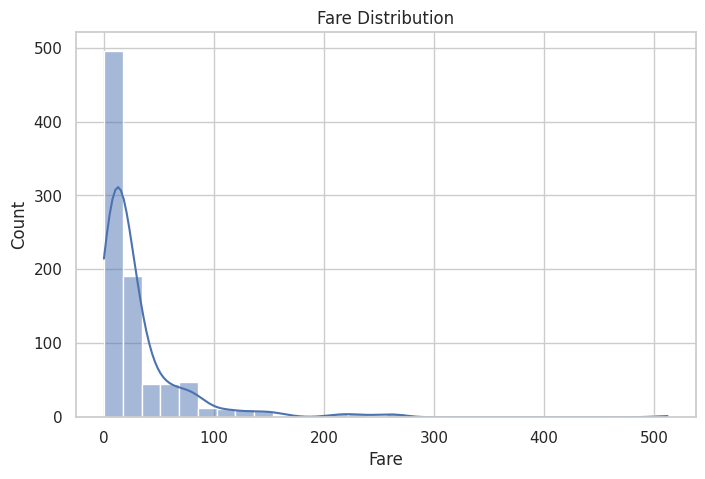

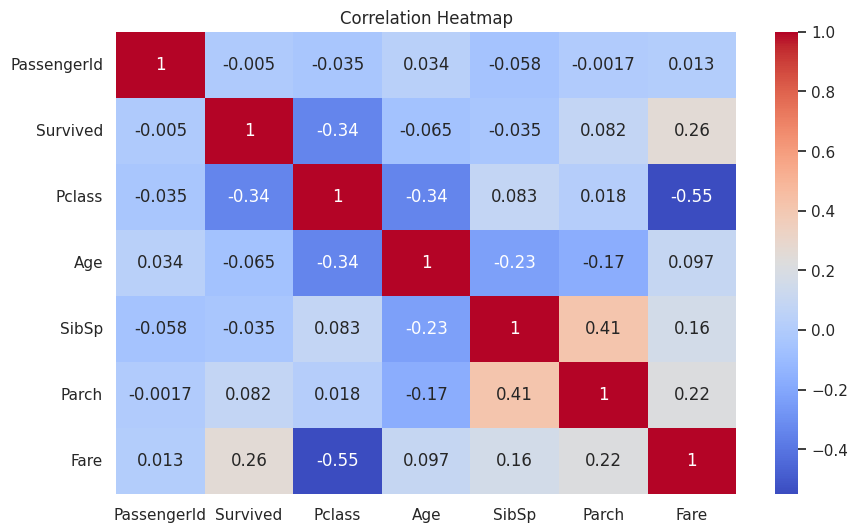


Key Findings:
Overall Survival Rate: 38.38%
Female Survival Rate: 74.20%
Male Survival Rate: 18.89%
First Class Survival Rate: 62.96%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/train.csv")

print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# Data Cleaning
# -----------------------------

df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# -----------------------------
# Basic Analysis
# -----------------------------

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------
# Visualizations
# -----------------------------

sns.set(style="whitegrid")

# Survival Count
plt.figure(figsize=(6,5))

sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival Count")

plt.show()

# Passenger Class
plt.figure(figsize=(6,5))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")

plt.show()

# Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.show()

# Survival by Gender
plt.figure(figsize=(7,5))

sns.countplot(x="Sex",
              hue="Survived",
              data=df)

plt.title("Survival Based on Gender")

plt.show()

# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Age"],
             bins=20,
             kde=True)

plt.title("Age Distribution")

plt.show()

# Fare Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"],
             bins=30,
             kde=True)

plt.title("Fare Distribution")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# -----------------------------
# Key Findings
# -----------------------------

print("\nKey Findings:")

overall_survival = df["Survived"].mean() * 100

print(f"Overall Survival Rate: {overall_survival:.2f}%")

female_survival = (
    df[df["Sex"] == "female"]["Survived"].mean() * 100
)

male_survival = (
    df[df["Sex"] == "male"]["Survived"].mean() * 100
)

print(f"Female Survival Rate: {female_survival:.2f}%")

print(f"Male Survival Rate: {male_survival:.2f}%")

first_class = (
    df[df["Pclass"] == 1]["Survived"].mean() * 100
)

print(f"First Class Survival Rate: {first_class:.2f}%")